In [1]:
# Standard libraries
import json
import random
import re
from itertools import count

# Scientific computing
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

# Gymnasium
import gymnasium as gym
from gymnasium import spaces

# Environment
from environment.job_scheduling.eval import Eval_JobSchedulingEnv
from environment.job_scheduling.train import Train_JobSchedulingEnv


In [2]:
# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

# ---------------------------
# Reproducibility Settings
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if hasattr(torch, "mps") and torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

In [3]:
# Memory for PPO
class PPOMemory():
    def __init__(self, batch_size):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []
        self.batch_size = batch_size

    def store(self, state, action, log_prob, value, reward, done):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.dones.append(done)

    def generate_batches(self):
        n = len(self.states)
        indices = np.arange(n)
        np.random.shuffle(indices)
        batch_starts = np.arange(0, n, self.batch_size)
        batches = [indices[i:i+self.batch_size] for i in batch_starts]
        return (
            np.array(self.states),
            np.array(self.actions),
            np.array(self.log_probs),
            np.array(self.values),
            np.array(self.rewards),
            np.array(self.dones),
            batches
        )

    def clear(self):
        self.__init__(self.batch_size)

In [4]:
class ActorNet(nn.Module):
    def __init__(self, input_dim, output_dim, lr, checkpoint_file,
                 hidden_size=256, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.drop2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_size, output_dim)
        self.checkpoint_file = checkpoint_file
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.to(device)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        logits = self.fc3(x)
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs)
        return dist, probs

    def save(self):
        torch.save(self.state_dict(), self.checkpoint_file)

    def load(self):
        self.load_state_dict(torch.load(self.checkpoint_file))

In [5]:
# Critic network
class CriticNet(nn.Module):
    def __init__(self, input_dim, lr, checkpoint_file,
                 hidden_size=256, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.drop2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_size, 1)
        self.checkpoint_file = checkpoint_file
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.to(device)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        value = self.fc3(x)
        return value

    def save(self):
        torch.save(self.state_dict(), self.checkpoint_file)

    def load(self):
        self.load_state_dict(torch.load(self.checkpoint_file))

In [6]:
# Flatten observation
def flatten_obs(obs):
    gpu_state = obs['gpu_state'].flatten()
    current_job = np.concatenate([obs['current_job']['one_hot'], [obs['current_job']['batch_size']]])
    future_stats = obs['future_job_stats'].flatten()
    jobs_left = np.array([obs['jobs_left']], dtype=np.float32)  # Normalized
    return np.concatenate([gpu_state, current_job, future_stats, jobs_left])


# Masking utility
def get_valid_action_indices(env):
    valid = []
    j = env.current_job_idx
    if env.assignment[j].sum() > 0:
        return valid
    for s in range(env.S):
        for a in range(env.A):
            colocated = [jj for jj in range(env.J)
                         if jj!=j and env.assignment[jj, s, a]>0]
            if len(colocated) < 2:
                valid.append(s*env.A + a)
    return valid

In [7]:
# Evaluation
def select_action_eval(state, env, actor_model):
    st = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        _, probs = actor_model(st)
    mask = torch.zeros_like(probs)
    mask[0, get_valid_action_indices(env)] = 1
    masked = probs*mask
    masked = masked/masked.sum(dim=-1, keepdim=True)
    return int(torch.argmax(masked, dim=-1).item())


def evaluate_model(actor_model, env, episodes=20):
    set_files = env.set_files
    rewards = []
    for ep in range(episodes):
        obs, _ = env.reset()
        state = flatten_obs(obs)
        done=False; total=0
        while not done:
            a_idx = select_action_eval(state, env, actor_model)
            s,a = divmod(a_idx, env.A)
            obs, rew, term, trunc, _ = env.step((s,a))
            total += sum(rew)
            done=term or trunc
            state = flatten_obs(obs) if not done else None
        rewards.append(total)
    mean = np.mean(rewards)
    return mean, rewards, set_files

In [8]:
# PPO Agent
class PPOAgent:
    def __init__(self, state_dim, action_dim, lr_actor, lr_critic, gamma, lamda,
                 clip, epochs, batch_size,
                 ent_start=0.1, ent_end=0.01, ent_decay=0.99):
        self.gamma = gamma
        self.lamda = lamda
        self.clip = clip
        self.epochs = epochs
        self.ent_coef = ent_start
        self.ent_end = ent_end
        self.ent_decay = ent_decay

        self.actor = ActorNet(state_dim, action_dim, lr_actor, 'models/job_scheduling/ppo/actor.pth')
        self.critic = CriticNet(state_dim, lr_critic, 'models/job_scheduling/ppo/critic.pth')
        self.memory = PPOMemory(batch_size)

    def choose_action(self, state, env):
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        dist, probs = self.actor(state_t)
        mask = torch.zeros_like(probs)
        idxs = get_valid_action_indices(env)
        mask[0, idxs] = 1
        masked = probs * mask
        masked = masked / masked.sum(dim=-1, keepdim=True)
        masked_dist = Categorical(masked)
        action = masked_dist.sample()
        logp = masked_dist.log_prob(action).item()
        val = self.critic(state_t).squeeze().item()
        return action.item(), logp, val

    def store(self, *args):
        self.memory.store(*args)

    def learn(self):
        states, actions, old_logp, vals, rewards, dones, batches = self.memory.generate_batches()
        # GAE
        advantages = np.zeros_like(rewards, dtype=float)
        gae = 0
        for t in reversed(range(len(rewards))):
            next_val = 0 if t==len(rewards)-1 else vals[t+1]
            mask = 1 - dones[t]
            delta = rewards[t] + self.gamma*next_val*mask - vals[t]
            gae = delta + self.gamma*self.lamda*mask*gae
            advantages[t] = gae
        advantages = torch.tensor(advantages, dtype=torch.float32, device=device)
        # advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        vals_t = torch.tensor(vals, dtype=torch.float32, device=device)
        old_logp_t = torch.tensor(old_logp, dtype=torch.float32, device=device)

        for _ in range(self.epochs):
            for batch in batches:
                st = torch.tensor(states[batch], dtype=torch.float32, device=device)
                ac = torch.tensor(actions[batch], device=device)
                new_dist, _ = self.actor(st)
                new_logp = new_dist.log_prob(ac)
                ratio = (new_logp - old_logp_t[batch]).exp()
                surr1 = ratio * advantages[batch]
                surr2 = torch.clamp(ratio, 1-self.clip, 1+self.clip) * advantages[batch]
                entropy = new_dist.entropy().mean()
                actor_loss = -torch.min(surr1, surr2).mean() - self.ent_coef*entropy

                ret = advantages[batch] + vals_t[batch]
                critic_val = self.critic(st).squeeze()
                # critic_loss = F.mse_loss(critic_val, ret)
                # critic_loss = F.mse_loss(critic_val.unsqueeze(0), ret)
                critic_loss = F.mse_loss(critic_val.squeeze(), ret.squeeze())

                loss = actor_loss + 0.5*critic_loss
                self.actor.optimizer.zero_grad()
                self.critic.optimizer.zero_grad()
                loss.backward()
                
                # torch.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=0.5)
                # torch.nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=0.5)

                self.actor.optimizer.step()
                self.critic.optimizer.step()

        self.memory.clear()
        self.ent_coef = max(self.ent_end, self.ent_coef * self.ent_decay)

    def save(self):
        self.actor.save(); self.critic.save()

    def load(self):
        self.actor.load(); self.critic.load()

In [9]:
# Plot
def plot_learning_curve(scores, file='curves/ppo.png'):
    # Plot
    plt.plot(scores)
    plt.xlabel("Evaluation Iteration")
    plt.ylabel("Avg Reward")
    plt.title("PPO Evaluation Curve")
    plt.grid()
    plt.savefig(file)
    plt.show()

✅ Episode 20: New Best Model Saved. Mean Reward = 5.72827885
🖐 Episode 40: Mean Reward = 5.33643585
🖐 Episode 60: Mean Reward = 5.70413176
✅ Episode 80: New Best Model Saved. Mean Reward = 5.98748717
🖐 Episode 100: Mean Reward = 5.91555601
🖐 Episode 120: Mean Reward = 5.87125856
🖐 Episode 140: Mean Reward = 5.84161794
🖐 Episode 160: Mean Reward = 5.88769794
🖐 Episode 180: Mean Reward = 5.68093425
✅ Episode 200: New Best Model Saved. Mean Reward = 6.09029723
✅ Episode 220: New Best Model Saved. Mean Reward = 6.15138299
🖐 Episode 240: Mean Reward = 6.05598487
🖐 Episode 260: Mean Reward = 6.12502279
🖐 Episode 280: Mean Reward = 6.08403276
🖐 Episode 300: Mean Reward = 6.03290235
✅ Episode 320: New Best Model Saved. Mean Reward = 6.24190430
✅ Episode 340: New Best Model Saved. Mean Reward = 6.30277088
🖐 Episode 360: Mean Reward = 5.88655581
🖐 Episode 380: Mean Reward = 6.09535318
✅ Episode 400: New Best Model Saved. Mean Reward = 6.31257479
✅ Episode 420: New Best Model Saved. Mean Reward =

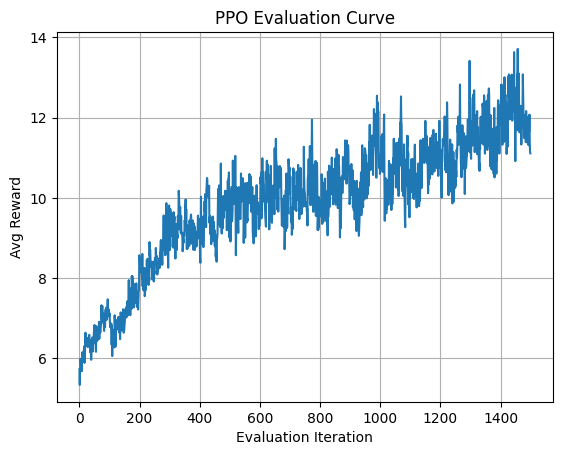

In [10]:
# Initialize environments
env = Train_JobSchedulingEnv()
observation, _ = env.reset()
state_dimension = flatten_obs(observation).shape[0]
action_dimension = env.S * env.A

train_env = Train_JobSchedulingEnv()
eval_env = Eval_JobSchedulingEnv("saved_job_sets")

# Initialize PPO Agent
ppo_agent = PPOAgent(
    state_dim=state_dimension,
    action_dim=action_dimension,
    lr_actor=1e-4,
    lr_critic=1e-3,
    gamma=0.99,
    lamda=0.95,
    clip=0.2,
    epochs=4,
    batch_size=64
)

learning_interval = 20
best_average_reward = -float("inf")
evaluation_scores = []
training_step_counter = 0

# Training Loop
for episode in range(30000):
    observation, _ = train_env.reset()
    flattened_state = flatten_obs(observation)
    episode_done = False
    cumulative_episode_reward = 0

    while not episode_done:
        action_index, log_prob, state_value = ppo_agent.choose_action(flattened_state, train_env)
        server_index, accelerator_index = divmod(action_index, train_env.A)
        observation, reward_list, terminated, truncated, _ = train_env.step((server_index, accelerator_index))
        episode_done = terminated or truncated
        reward_sum = sum(reward_list)

        ppo_agent.memory.store(flattened_state, action_index, log_prob, state_value, reward_sum, episode_done)
        training_step_counter += 1
        cumulative_episode_reward += reward_sum

        flattened_state = flatten_obs(observation) if not episode_done else None

    ppo_agent.learn()
    
    # Periodic Evaluation
    if (episode + 1) % 20 == 0:
        ppo_agent.actor.eval()
        mean_reward, _, _ = evaluate_model(
            ppo_agent.actor, eval_env, 20
        )
        ppo_agent.actor.train()

        evaluation_scores.append(mean_reward)
        if mean_reward > best_average_reward:
            print(f"✅ Episode {episode+1}: New Best Model Saved. Mean Reward = {mean_reward:.8f}")
            best_average_reward = mean_reward
            ppo_agent.save()
        else:
            print(f"🖐 Episode {episode+1}: Mean Reward = {mean_reward:.8f}")
            

# Plot final learning curve
plot_learning_curve(evaluation_scores, file='curves/job_scheduling/training_ppo.png')

# Save scores to a JSON file
with open('curves/job_scheduling/training_ppo.json', 'w') as f:
    json.dump(evaluation_scores, f)


In [11]:
ppo_agent.load()

ppo_agent.actor.eval()
eval_env = Eval_JobSchedulingEnv("saved_job_sets")
avg, rewards, set_files = evaluate_model(ppo_agent.actor, eval_env, episodes=20)
print("✅ External evaluation average rewards:", rewards)
print("Evaluation set files:", set_files)

# Save scores to a JSON file
with open('curves/job_scheduling/evaluation_scores_ppo.json', 'w') as f:
    json.dump(rewards, f)

✅ External evaluation average rewards: [13.48446033240887, 14.302022043822427, 14.705807922718332, 15.81383653659017, 14.740383135147368, 15.086021229932284, 11.268355008178048, 9.493893112095698, 11.788695875127907, 10.448820489339877, 18.42529568221465, 14.72822960686798, 11.62881898394031, 14.463107249971198, 12.497041701904806, 13.812028382111565, 16.97116240787668, 11.244957940948426, 16.7753009647631, 12.609314939252043]
Evaluation set files: ['saved_job_sets/set_000.json', 'saved_job_sets/set_001.json', 'saved_job_sets/set_002.json', 'saved_job_sets/set_003.json', 'saved_job_sets/set_004.json', 'saved_job_sets/set_005.json', 'saved_job_sets/set_006.json', 'saved_job_sets/set_007.json', 'saved_job_sets/set_008.json', 'saved_job_sets/set_009.json', 'saved_job_sets/set_010.json', 'saved_job_sets/set_011.json', 'saved_job_sets/set_012.json', 'saved_job_sets/set_013.json', 'saved_job_sets/set_014.json', 'saved_job_sets/set_015.json', 'saved_job_sets/set_016.json', 'saved_job_sets/set